<a href="https://colab.research.google.com/github/denisadwi793/Submission/blob/main/target.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mealpy numpy pandas matplotlib
!pip install "mealpy>=3.0.1" numpy pandas matplotlib


In [2]:
import mealpy
print(mealpy.__version__)

3.0.3


In [3]:
from mealpy.swarm_based import HBA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mealpy import FloatVar, IntegerVar, Problem          # << penting: Problem & Var types
from mealpy.swarm_based import HBA
from mealpy.utils.space import IntegerVar

In [4]:
from google.colab import files
uploaded = files.upload()

Saving data seminar.xlsx to data seminar.xlsx


In [5]:
df = pd.read_excel("data seminar.xlsx")
df

,Item,Meand Demand,St dv demand,Starting stock,Selling price,Ordering cost,Holding cost,Space cost,Probability
0,1,5714,150,5813,50,1309,28,5,1.0
1,2,4199,245,4292,43,1235,32,6,1.00.8
2,3,4674,295,4860,15,811,37,6,0.6
3,4,5131,195,5128,50,933,34,4,NaN


In [6]:
# Replace the non-numeric value '1.00.8' with 0.8
df['Probability'] = df['Probability'].replace('1.00.8', 0.8)

# Convert the 'Probability' column to numeric, coercing errors
df['Probability'] = pd.to_numeric(df['Probability'], errors='coerce')

# Fill the missing value (NaN) with the mean of the 'Probability' column
df['Probability'] = df['Probability'].fillna(df['Probability'].mean())

print("Dataframe setelah dibersihkan:")
display(df)

Dataframe setelah dibersihkan:


,Item,Meand Demand,St dv demand,Starting stock,Selling price,Ordering cost,Holding cost,Space cost,Probability
0,1,5714,150,5813,50,1309,28,5,1.0
1,2,4199,245,4292,43,1235,32,6,0.8
2,3,4674,295,4860,15,811,37,6,0.6
3,4,5131,195,5128,50,933,34,4,0.8


In [7]:
I = len(df)          # jumlah item
J = 3

In [8]:
demand_cols = [f"d_{j+1}" for j in range(J)] if all([f"d_{j+1}" in df.columns for j in range(J)]) else None
if demand_cols:
    Dmat = df[demand_cols].to_numpy(dtype=float)   # demand per periode
else:
    base = df["St dv demand"].to_numpy(dtype=float)

    Dmat = np.tile(base.reshape(I,1), (1,J))

In [9]:
RS = df["Space cost"].to_numpy(dtype=float)

In [10]:
def vec_to_Q(solution):
    """reshape kromosom (length I*J) jadi matriks Q (I x J)"""
    arr = np.array(solution, dtype=int).reshape(I, J)
    return arr

In [11]:
   def fitness_function(solution, lambda_short=1000.0):
    Q = vec_to_Q(solution)   # order quantities (I x J)

    total_space = 0.0
    penalty = 0.0

    # inventory awal (anggap nol semua)
    IL = np.zeros((I, J+1))

    for j in range(J):
        # update inventory
        IL[:, j+1] = IL[:, j] + Q[:, j] - Dmat[:, j]

        # Hitung penggunaan ruang (bisa pilih definisi):
        # a) berdasarkan stok akhir positif (lebih intuitif)
        total_space += np.sum(np.maximum(IL[:, j+1], 0) * RS)

        # Penalti shortage (stok negatif → kekurangan)
        shortage = np.maximum(-IL[:, j+1], 0)
        penalty += np.sum(shortage) * lambda_short

    return total_space + penalty

In [12]:
# Define bounds for the multi-period problem (I * J variables)
lb = [10] * (I * J)
ub = [10000] * (I * J)
bounds = IntegerVar(lb=lb, ub=ub)

problem = Problem(
    obj_func=fitness_function,
    bounds=bounds,
    minmax="min",
    name="Inventory_Min_Space_MultiPeriod"
)

In [16]:
model = HBA.OriginalHBA(epoch=500, pop_size=30, seed=42)
result = model.solve(problem)

INFO:mealpy.swarm_based.HBA.OriginalHBA:OriginalHBA(epoch=500, pop_size=30)
INFO:mealpy.swarm_based.HBA.OriginalHBA:>>>Problem: Inventory_Min_Space_MultiPeriod, Epoch: 1, Current best: 241291.0, Global best: 241291.0, Runtime: 0.05416 seconds
INFO:mealpy.swarm_based.HBA.OriginalHBA:>>>Problem: Inventory_Min_Space_MultiPeriod, Epoch: 2, Current best: 192358.0, Global best: 192358.0, Runtime: 0.05034 seconds
INFO:mealpy.swarm_based.HBA.OriginalHBA:>>>Problem: Inventory_Min_Space_MultiPeriod, Epoch: 3, Current best: 132866.0, Global best: 132866.0, Runtime: 0.01018 seconds
INFO:mealpy.swarm_based.HBA.OriginalHBA:>>>Problem: Inventory_Min_Space_MultiPeriod, Epoch: 4, Current best: 90003.0, Global best: 90003.0, Runtime: 0.06834 seconds
INFO:mealpy.swarm_based.HBA.OriginalHBA:>>>Problem: Inventory_Min_Space_MultiPeriod, Epoch: 5, Current best: 70114.0, Global best: 70114.0, Runtime: 0.05609 seconds
INFO:mealpy.swarm_based.HBA.OriginalHBA:>>>Problem: Inventory_Min_Space_MultiPeriod, Epoch: 6

In [26]:
print("=== HASIL OPTIMASI HBA ===")

if isinstance(result, dict):                  # versi lama (dict)
    best_f = float(result["best_f"])
    best_sol = np.array(result["best_solution"])
else:                                         # versi baru (object)
    best_f = float(result.target.fitness)             # directly access the fitness attribute
    best_sol = np.array(result.solution)

print(f"Fitness terbaik : {best_f:.2f}\n")

# Matriks Order Quantity terbaik
best_solution = vec_to_Q(best_sol)
print("Matriks Order Quantity (Q):")
print(pd.DataFrame(
    best_solution,
    index=[f"Item {i+1}" for i in range(I)],
    columns=[f"Periode {j+1}" for j in range(J)]
).to_string())

=== HASIL OPTIMASI HBA ===
Fitness terbaik : 5890.00

Matriks Order Quantity (Q):
        Periode 1  Periode 2  Periode 3
Item 1        168        132        170
Item 2        661         37         37
Item 3        512         78        296
Item 4        248        142        304


In [28]:
# Ambil solusi terbaik (matrix Q)
best_solution = vec_to_Q(result.solution)

# Inventory awal nol
IL = np.zeros((I, J+1))
storage_per_item = np.zeros(I)

for j in range(J):
    IL[:, j+1] = IL[:, j] + best_solution[:, j] - Dmat[:, j]
    # ruang = stok akhir positif * RS
    storage_per_item += np.maximum(IL[:, j+1], 0) * RS

# Buat DataFrame rapi
df_storage = pd.DataFrame({
    "Item": [f"Item {i+1}" for i in range(I)],
    "Total_Storage_Space": storage_per_item
})

print("\n=== Storage Space per Item ===")
print(df_storage.to_string(index=False))



=== Storage Space per Item ===
  Item  Total_Storage_Space
Item 1                190.0
Item 2               3744.0
Item 3               1308.0
Item 4                648.0


In [29]:
# Ambil solusi terbaik (matrix Q)
best_solution = vec_to_Q(result.solution)

# Inventory awal nol
IL = np.zeros((I, J+1))
storage_matrix = np.zeros((I, J))   # space per item x periode

for j in range(J):
    IL[:, j+1] = IL[:, j] + best_solution[:, j] - Dmat[:, j]
    # ruang periode j untuk tiap item
    storage_matrix[:, j] = np.maximum(IL[:, j+1], 0) * RS

# Buat DataFrame rapi
df_storage = pd.DataFrame(
    storage_matrix,
    index=[f"Item {i+1}" for i in range(I)],
    columns=[f"Periode {j+1}" for j in range(J)]
)

# Tambahkan total per item (baris)
df_storage["Total"] = df_storage.sum(axis=1)

# Tambahkan total per periode (kolom)
totals_row = df_storage.sum(axis=0).to_frame().T
totals_row.index = ["Grand Total"]

# Gabungkan
df_storage = pd.concat([df_storage, totals_row])

print("\n=== Storage Space per Item & Periode ===")
print(df_storage.to_string())




=== Storage Space per Item & Periode ===
             Periode 1  Periode 2  Periode 3   Total
Item 1            90.0        0.0      100.0   190.0
Item 2          2496.0     1248.0        0.0  3744.0
Item 3          1302.0        0.0        6.0  1308.0
Item 4           212.0        0.0      436.0   648.0
Grand Total     4100.0     1248.0      542.0  5890.0


In [30]:
solution_history = np.array([agent.solution for agent in model.history.list_global_best])

In [31]:
space_cost = df["Space cost"].values

In [32]:
# Ensure epochs is set based on the shape of solution_history
epochs = solution_history.shape[0]

storage_contrib = np.zeros((epochs, I)) # Initialize array to store storage contribution per item per epoch

for epoch in range(epochs):
    # Get the solution for the current epoch (1D array of size I*J)
    solution_epoch = solution_history[epoch]

    # Reshape the solution into the Q matrix (I x J)
    Q_matrix = solution_epoch.reshape(I, J)

    # Calculate the total order quantity for each item across all periods
    total_order_qty_per_item = np.sum(Q_matrix, axis=1)

    # Calculate the storage contribution for each item at this epoch
    storage_contrib[epoch, :] = total_order_qty_per_item * space_cost

In [33]:
n_items = storage_contrib.shape[1]

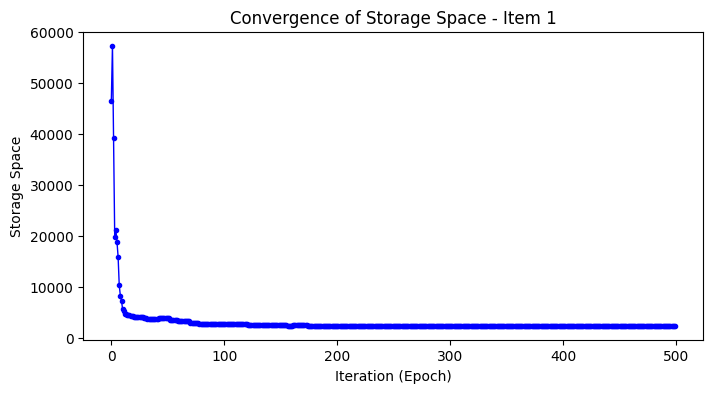

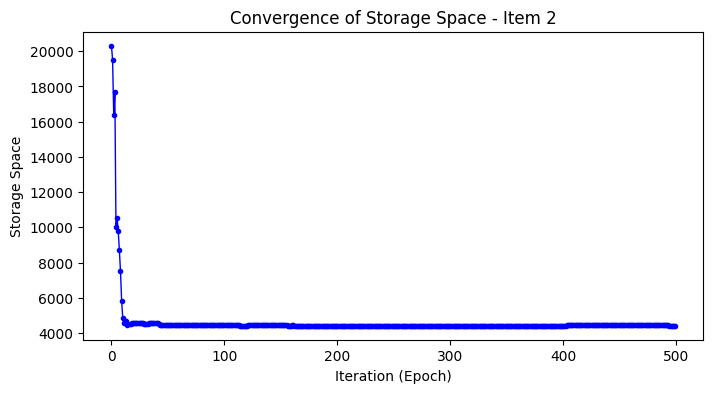

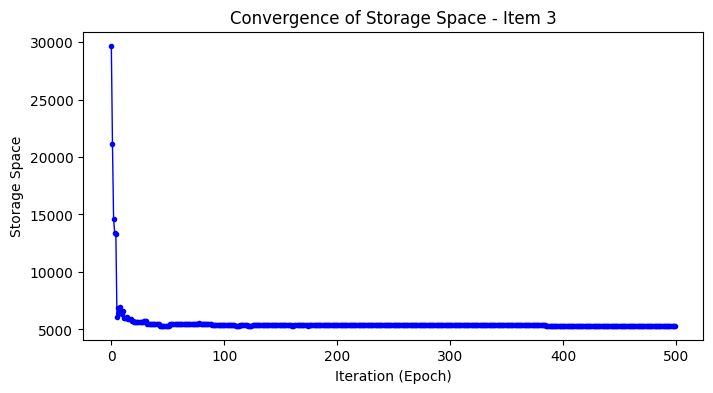

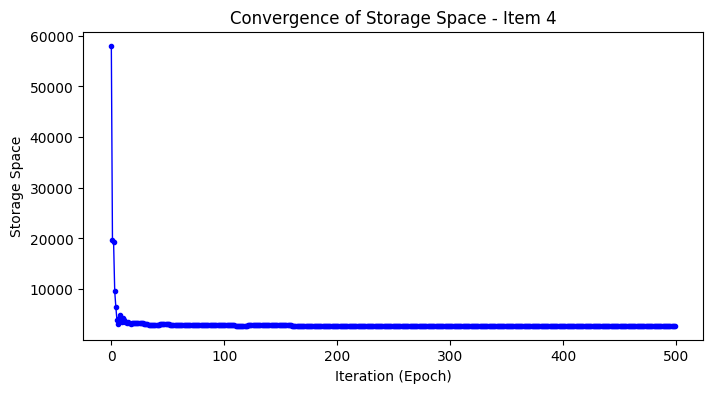

In [34]:
for i in range(n_items):
    plt.figure(figsize=(8,4))
    plt.plot(storage_contrib[:, i], color='blue', marker='o', markersize=3, linewidth=1)
    plt.xlabel("Iteration (Epoch)")
    plt.ylabel("Storage Space")
    plt.title(f"Convergence of Storage Space - Item {i+1}")
    plt.grid(False)
    plt.show()

/tmp/ipython-input-165475374.py:12: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, linestyle="--", alpha=0.5)


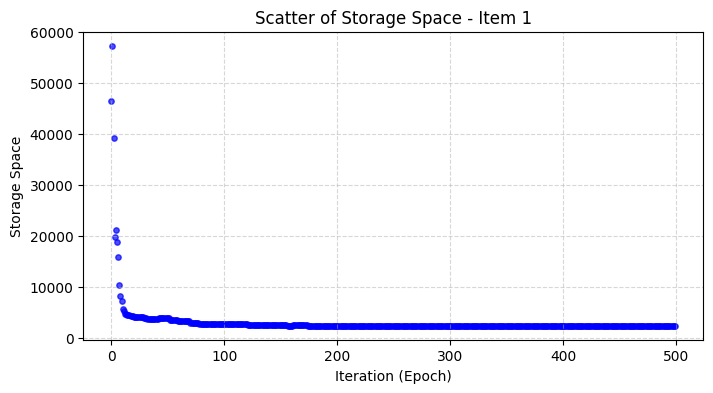

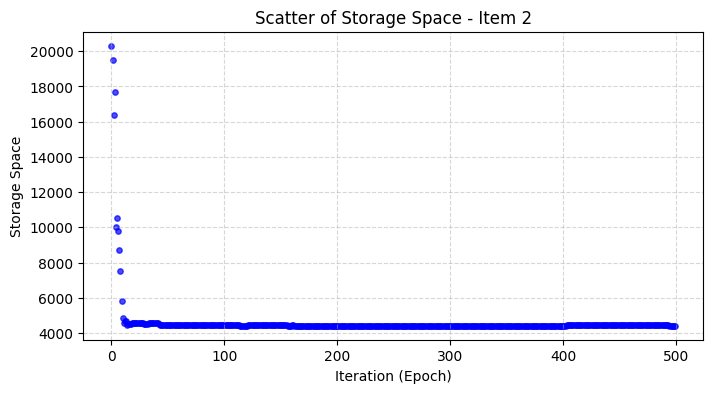

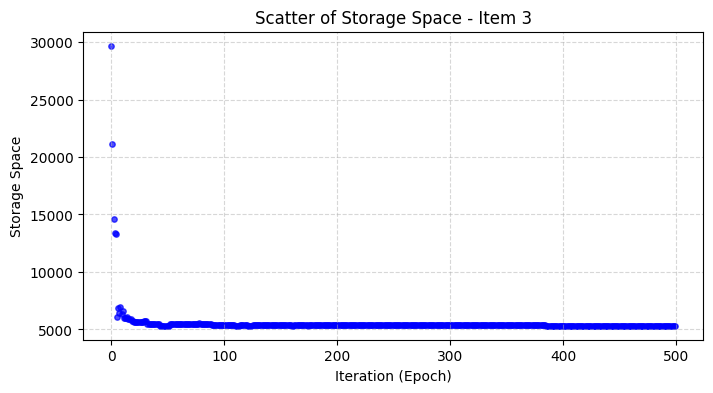

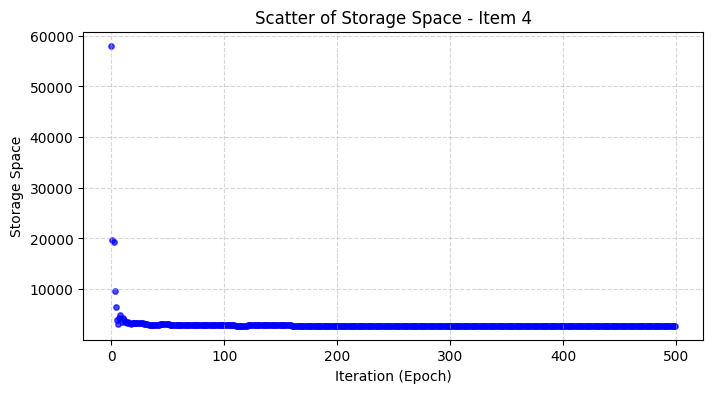

In [35]:
for i in range(n_items):
    plt.figure(figsize=(8,4))

    # Scatter plot (bukan line plot)
    plt.scatter(range(len(storage_contrib[:, i])),
                storage_contrib[:, i],
                color='blue', s=15, alpha=0.7)

    plt.xlabel("Iteration (Epoch)")
    plt.ylabel("Storage Space")
    plt.title(f"Scatter of Storage Space - Item {i+1}")
    plt.grid(False, linestyle="--", alpha=0.5)
    plt.show()


In [36]:
import copy

In [37]:
def vec_to_Q(solution):
    global I, J
    arr = np.array(solution, dtype=int).reshape(I, J)
    return arr

In [38]:
def fitness_function(solution):
    Q = vec_to_Q(solution)  # reshape kromosom ke matriks (I x J)

    # --- Hitung storage space (m²) ---
    storage_space = np.sum(Q * RS[:, None])   # Q(i,j) * RS(i) lalu dijumlah

    # --- Demand satisfaction ---
    produced = np.sum(Q, axis=1)  # total produksi tiap item
    unmet = np.sum(np.maximum(0, Dmat.sum(axis=1) - produced))  # unmet demand
    penalty = unmet * 1e6   # penalti besar biar demand terpenuhi

    # Return tuple -> fitness (buat HBA), storage_space (buat laporan)
    return float(storage_space + penalty), storage_space


In [39]:
def run_HBA(df_temp):
    global Dmat, RS, I, J   # ambil variabel global

    # --- regenerate matrices sesuai df_temp ---
    demand_cols = [f"d_{j+1}" for j in range(J)] if all([f"d_{j+1}" in df_temp.columns for j in range(J)]) else None
    if demand_cols:
        Dmat = df_temp[demand_cols].to_numpy(dtype=float)
    else:
        base = df_temp["St dv demand"].to_numpy(dtype=float)
        Dmat = np.tile(base.reshape(I,1), (1,J))

    RS = df_temp["Space cost"].to_numpy(dtype=float)

    # --- jalankan HBA ---
    g_best = HBA_min_space(df_temp, I, J, bounds)

    # --- ambil hasil fitness + storage ---
    f, storage = fitness_function(g_best)
    return storage


In [40]:
def HBA_min_space(df, I, J, bounds, n_agents=30, max_iter=100):
    dim = I * J
    lb, ub = bounds.lb[0], bounds.ub[0]

    population = np.random.randint(lb, ub+1, size=(n_agents, dim))
    fitness_vals = []
    for ind in population:
        f, _ = fitness_function(ind)
        fitness_vals.append(f)
    fitness_vals = np.array(fitness_vals)

    g_best = population[np.argmin(fitness_vals)]
    g_best_fit = fitness_vals.min()

    for t in range(max_iter):
        for i in range(n_agents):
            new_solution = population[i] + np.random.randint(-5, 6, size=dim)
            new_solution = np.clip(new_solution, lb, ub)
            f_new, _ = fitness_function(new_solution)
            if f_new < fitness_vals[i]:
                population[i] = new_solution
                fitness_vals[i] = f_new
                if f_new < g_best_fit:
                    g_best = new_solution
                    g_best_fit = f_new

    return type("Best", (), {"solution": g_best, "fitness": g_best_fit})


In [41]:
def run_HBA(df_temp):
    global Dmat, RS, I, J
    demand_cols = [f"d_{j+1}" for j in range(J)] if all([f"d_{j+1}" in df_temp.columns for j in range(J)]) else None
    if demand_cols:
        Dmat = df_temp[demand_cols].to_numpy(dtype=float)
    else:
        base = df_temp["St dv demand"].to_numpy(dtype=float)
        Dmat = np.tile(base.reshape(I,1), (1,J))
    RS = df_temp["Space cost"].to_numpy(dtype=float)

    g_best = HBA_min_space(df_temp, I, J, bounds)
    f, storage = fitness_function(g_best.solution)
    return storage


In [42]:
scenarios = [
    ("Base", {}),

    # Demand scenarios
    ("Demand -50%", {"St dv demand": 0.5}),
    ("Demand -20%", {"St dv demand": 0.8}),
    ("Demand +10%", {"St dv demand": 1.1}),
    ("Demand +20%", {"St dv demand": 1.2}),
    ("Demand +50%", {"St dv demand": 1.5}),

    # Space Cost scenarios
    ("Space -50%", {"Space cost": 0.5}),
    ("Space -20%", {"Space cost": 0.8}),
    ("Space +10%", {"Space cost": 1.1}),
    ("Space +20%", {"Space cost": 1.2}),
    ("Space +50%", {"Space cost": 1.5}),
]


In [43]:
results = []

In [44]:
for label, changes in scenarios:
    df_temp = df.copy()
    for col, factor in changes.items():
        df_temp[col] = df_temp[col] * factor   # modifikasi kolom sesuai faktor

    storage = run_HBA(df_temp)                 # jalankan HBA
    results.append([label, storage])


In [45]:
results_df = pd.DataFrame(results, columns=["Scenario", "Storage Space"])

In [46]:
print(results_df)

       Scenario  Storage Space
0          Base       177566.0
1   Demand -50%       190119.0
2   Demand -20%       238971.0
3   Demand +10%       194051.0
4   Demand +20%       141774.0
5   Demand +50%       199265.0
6    Space -50%       106626.5
7    Space -20%       163765.6
8    Space +10%       198130.9
9    Space +20%       210507.6
10   Space +50%       308518.5


In [47]:
print("\n=== Sensitivity Analysis ===")
print(results_df.to_string(index=False))


=== Sensitivity Analysis ===
   Scenario  Storage Space
       Base       177566.0
Demand -50%       190119.0
Demand -20%       238971.0
Demand +10%       194051.0
Demand +20%       141774.0
Demand +50%       199265.0
 Space -50%       106626.5
 Space -20%       163765.6
 Space +10%       198130.9
 Space +20%       210507.6
 Space +50%       308518.5


In [48]:
# Example scenarios and storage_spaces (not used for actual plotting)
# scenarios = ["-30%", "-20%", "-10%", "Normal", "+10%", "+20%", "+30%"]
# storage_spaces = [9500, 9800, 10050, 10200, 10400, 10750, 11000]

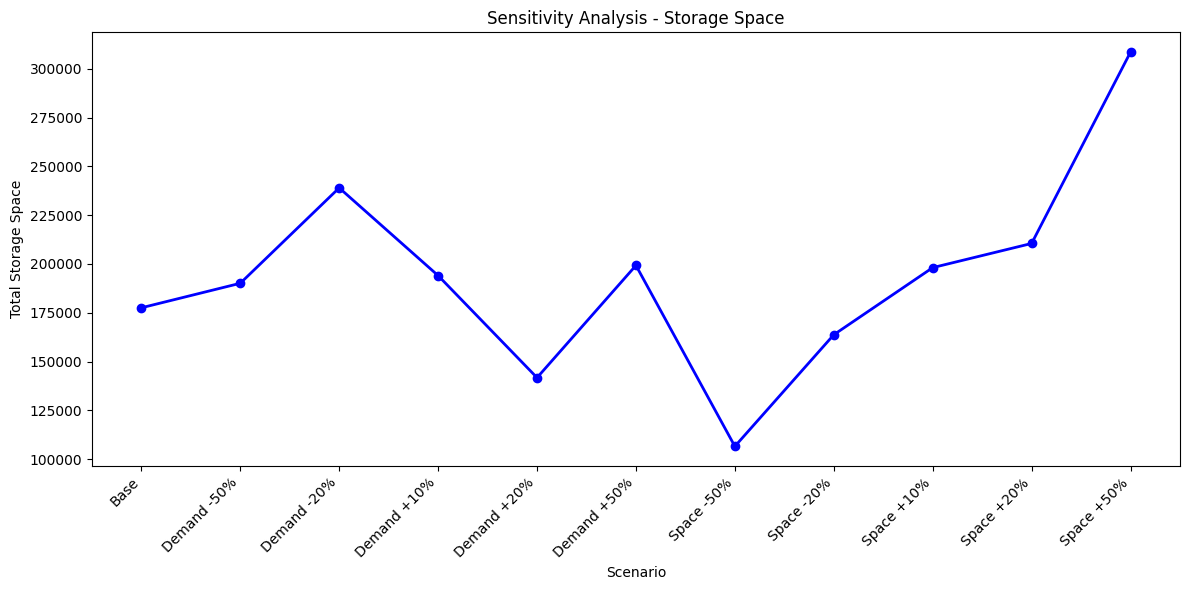

In [49]:
# Use results_df from the sensitivity analysis for plotting
plt.figure(figsize=(12, 6))
plt.plot(results_df["Scenario"], results_df["Storage Space"], marker="o", linestyle="-", linewidth=2, color="blue")
plt.title("Sensitivity Analysis - Storage Space")
plt.xlabel("Scenario")
plt.ylabel("Total Storage Space")
plt.xticks(rotation=45, ha="right") # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

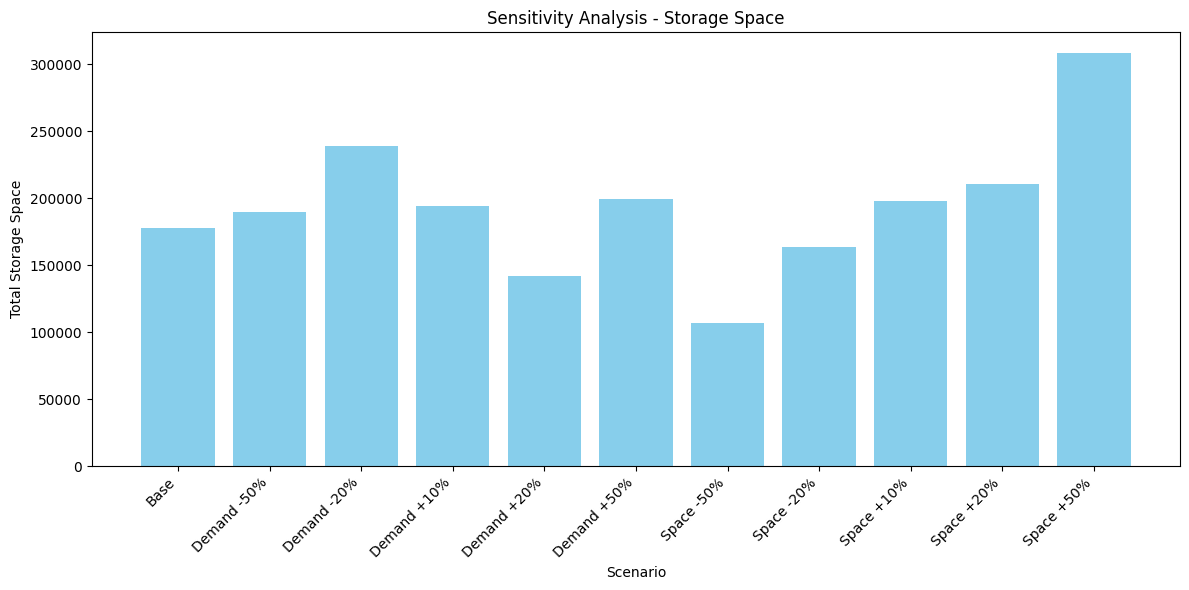

In [50]:
# Use results_df from the sensitivity analysis for plotting
plt.figure(figsize=(12, 6))
plt.bar(results_df["Scenario"], results_df["Storage Space"], color="skyblue")
plt.title("Sensitivity Analysis - Storage Space")
plt.xlabel("Scenario")
plt.ylabel("Total Storage Space")
plt.xticks(rotation=45, ha="right") # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()